# Lab 9: Mixed areas and the Brunn–Minkowski box cut
**Python supplement · Worked solutions · English**

Compute volume-growth coefficients and visualize the matching cut in the
inductive proof. These two exercises supplement the 90-minute mathematical
lab; allow about 70–90 additional minutes or assign them as homework.

Run the setup first and work from top to bottom. The student functions
return `None` until completed, so the demonstration cells report what to
finish before running their checks. In the solution version the functions
are complete and all figures and checks run with a fresh kernel.

Distinguish exact identities for represented polygons/rectangle unions
from curved-shape approximation, floating-point error and finite numerical
evidence. The course supplies the mathematical proof of the inequalities.


Use [the notebook setup guide](../README.md).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')

from scipy.spatial import ConvexHull, QhullError

from matplotlib.patches import Rectangle


## Exercise 9.1: Polygon sums and the mixed-area coefficient

For convex polygons $K,L$, their Minkowski sum is the convex hull of
**all** vertex sums $v_i+w_j$. Generally, adding only corresponding
vertices misses part of the sum. Mixed area satisfies
$A(K+tL)=A(K)+2tV(K,L)+t^2A(L)$.

**Code tasks (35–45 minutes).**
1. Complete `minkowski_data(K,L,parameters)`: form all pairwise sums,
   extract the counterclockwise convex hull, and compute mixed area
   from the areas at $t=0$ and $t=1$.
2. Independently compute the area of each hull $K+tL$ at the supplied
   parameters; compare with the quadratic formula and the
   Brunn–Minkowski lower bound. Draw $K,L,K+L$.
3. Check support addition and a homothetic equality case. Replace $L$
   by an inscribed regular approximation $B_m$ of the unit disk and
   investigate $2V(K,B_m)\to P(K)$ as $m$ increases.

**Return contract:** `(sum_vertices, mixed_area, sampled_areas)`.
Inputs are ordered full-dimensional convex polygons; parameter values
are nonnegative. Use the supplied `area`, `perimeter` and `outline`
helpers. In 2D, `ConvexHull(...).vertices` gives cyclic hull order;
`hull.area` would give perimeter, not area.


In [2]:
def minkowski_data(K,L,parameters):
    def add_polygons(first,second):
        points=(first[:,None,:]+second[None,:,:]).reshape(-1,2)
        return points[ConvexHull(points).vertices]
    summed=add_polygons(K,L)
    mixed=(area(summed)-area(K)-area(L))/2
    sampled=np.array([area(add_polygons(K,t*L)) for t in parameters])
    return summed,mixed,sampled


**Run, visualize and check.** Change the suggested inputs after the default checks pass.

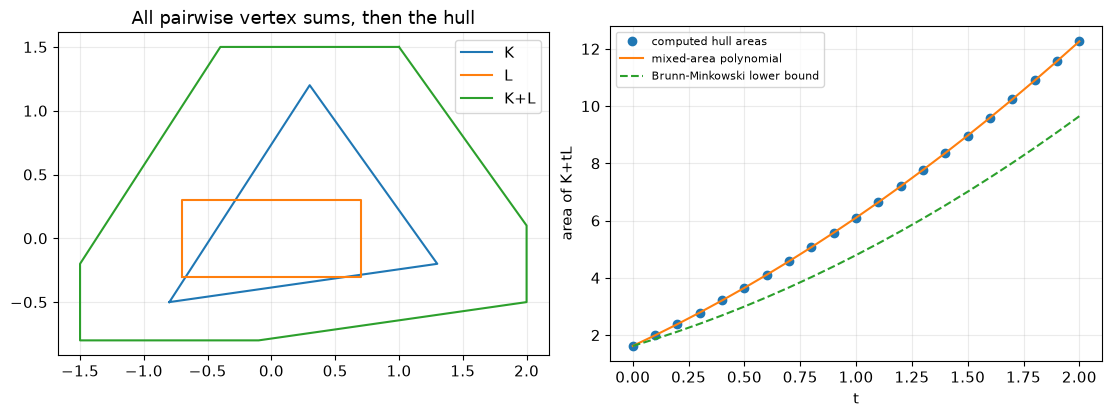

Disk with   8 vertices: 2V=5.7769553, perimeter gap=0.08967581
Disk with  32 vertices: 2V=5.8624295, perimeter gap=0.004201597
Disk with 128 vertices: 2V=5.8661053, perimeter gap=0.000525811
Mixed area: 1.8199999999999998 ; squared inequality gap: 1.9515999999999993


In [3]:
K=np.array([[-.8,-.5],[1.3,-.2],[.3,1.2]])
L=np.array([[-.7,-.3],[.7,-.3],[.7,.3],[-.7,.3]])
parameters=np.linspace(0,2,21)
result=minkowski_data(K,L,parameters)
if result is None:
    print('Complete minkowski_data, then rerun this cell.')
else:
    summed,mixed,measured=result
    predicted=area(K)+2*parameters*mixed+parameters**2*area(L)
    lower=(np.sqrt(area(K))+parameters*np.sqrt(area(L)))**2
    np.testing.assert_allclose(measured,predicted,atol=1e-11)
    assert np.all(measured >= lower-1e-11)
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for v,label in [(K,'K'),(L,'L'),(summed,'K+L')]:
        outline(axes[0],v,label=label)
    axes[0].legend(); axes[0].set_title('All pairwise vertex sums, then the hull')
    axes[1].plot(parameters,measured,'o',label='computed hull areas')
    axes[1].plot(parameters,predicted,label='mixed-area polynomial')
    axes[1].plot(parameters,lower,'--',label='Brunn-Minkowski lower bound')
    axes[1].set(xlabel='t',ylabel='area of K+tL'); axes[1].legend(fontsize=8)
    plt.show()
    angles=np.linspace(0,2*np.pi,301)
    directions=np.column_stack([np.cos(angles),np.sin(angles)])
    np.testing.assert_allclose((summed @ directions.T).max(0),
                               (K @ directions.T).max(0)+(L @ directions.T).max(0),atol=1e-12)
    _,homothetic,hom_areas=minkowski_data(K,2*K+np.array([3.,-1.]),parameters)
    np.testing.assert_allclose(homothetic,2*area(K),atol=1e-11)
    np.testing.assert_allclose(hom_areas,(1+2*parameters)**2*area(K),atol=1e-11)
    np.testing.assert_allclose(minkowski_data(L,K,[1.])[1],mixed,atol=1e-12)
    for count in (8,32,128):
        theta=2*np.pi*np.arange(count)/count
        disk_polygon=np.column_stack([np.cos(theta),np.sin(theta)])
        twice_mixed=2*minkowski_data(K,disk_polygon,[1.])[1]
        error=perimeter(K)-twice_mixed
        assert error >= -1e-11
        print(f'Disk with {count:3d} vertices: 2V={twice_mixed:.7f}, perimeter gap={error:.7g}')
    assert error < .005
    print('Mixed area:',mixed,'; squared inequality gap:',mixed**2-area(K)*area(L))


**Explain your observations.** Why is the hull of corresponding vertex sums insufficient in general? Which checks are exact polygon identities up to roundoff, and which involve approximation of a curved body?

**Solution guidance:** Every point of a convex polygon is a convex combination of its vertices, so all pairwise vertex sums generate the full Minkowski sum by convex hull. Corresponding pairs are an arbitrary smaller list. The polynomial and support identities are exact for the input polygons. The disk is approximated by an inscribed polygon, so its mixed area approaches the disk value from below. Matching a finite list of samples is a numerical check, not the proof of the volume-polynomial theorem.

## Exercise 9.2: Match a box cut by volume

Each row `[xmin,ymin,xmax,ymax]` represents a closed axis-aligned
rectangle. The supplied sets $E,F$ are unions of rectangles with
disjoint interiors. Split $E$ at $x=c=1.25$. Find a parallel cut
$x=e$ in $F$ such that
$|E^-|/|E|=|F^-|/|F|=\theta$.

**Code tasks (35–45 minutes).**
1. Complete `split_rectangles(boxes,cut)`, discarding pieces of zero area.
   Return the left and right arrays, each with four columns.
2. Complete `matching_cut(E,F,c)`: compute the left volume fraction of
   $E$, and use 60 bisection steps to find a cut in $F$ with the same
   fraction. Use the provided exact rectangle-union area helper.
3. Draw both cuts and the matching sums $E^-+F^-$ and $E^++F^+$.
   Compare their combined area, the full sum's area and the
   Brunn–Minkowski lower bound. Check the box count on each side.

**Return contracts:** `split_rectangles` returns `(left,right)`;
`matching_cut` returns `(Eminus,Eplus,Fminus,Fplus,e,theta)`.
Keep $1<c<2$ so the cut separates the first two boxes of $E$.
It also splits the third box, illustrating why counting pieces across
both sides is not the induction argument.

These are **unions**, not convex bodies. Do not replace them by a convex
hull or add the areas of overlapping rectangles. The helper sweeps vertical
slabs and merges covered intervals; its result has only floating-point
roundoff, not a pixel-resolution error.


**Provided geometry helpers.** Run this cell before implementing the task.

In [4]:
def union_area(boxes):
    """Area of an arbitrary finite rectangle union, including overlaps."""
    if len(boxes)==0:
        return 0.
    xs=np.unique(boxes[:,[0,2]])
    total=0.
    for left,right in zip(xs[:-1],xs[1:]):
        middle=(left+right)/2
        active=boxes[(boxes[:,0]<middle)&(middle<boxes[:,2])]
        intervals=sorted((row[1],row[3]) for row in active)
        if not intervals:
            continue
        lower,upper=intervals[0]
        length=0.
        for a,b in intervals[1:]:
            if a>upper:
                length+=upper-lower
                lower,upper=a,b
            else:
                upper=max(upper,b)
        total+=(right-left)*(length+upper-lower)
    return total

def rectangle_sums(first,second):
    # Adding two rectangles adds their lower and upper coordinates.
    return (first[:,None,:]+second[None,:,:]).reshape(-1,4)

def draw_boxes(ax,boxes,color,label,alpha=.3):
    for i,(x0,y0,x1,y1) in enumerate(boxes):
        ax.add_patch(Rectangle((x0,y0),x1-x0,y1-y0,facecolor=color,
                               edgecolor=color,alpha=alpha,label=label if i==0 else None))
    ax.autoscale_view(); ax.set_aspect('equal',adjustable='box')


In [5]:
def split_rectangles(boxes,cut):
    left,right=[],[]
    for x0,y0,x1,y1 in boxes:
        end=min(x1,cut)
        if end>x0:
            left.append([x0,y0,end,y1])
        start=max(x0,cut)
        if x1>start:
            right.append([start,y0,x1,y1])
    return np.asarray(left).reshape(-1,4),np.asarray(right).reshape(-1,4)

def matching_cut(E,F,c):
    Em,Ep=split_rectangles(E,c)
    theta=union_area(Em)/union_area(E)
    if not 0<theta<1:
        raise ValueError('The cut must leave positive area on both sides of E.')
    target=theta*union_area(F)
    low,high=F[:,0].min(),F[:,2].max()
    for _ in range(60):
        middle=(low+high)/2
        left,_=split_rectangles(F,middle)
        if union_area(left)<target:
            low=middle
        else:
            high=middle
    e=(low+high)/2
    Fm,Fp=split_rectangles(F,e)
    return Em,Ep,Fm,Fp,e,theta


**Run, visualize and check.** Change the suggested inputs after the default checks pass.

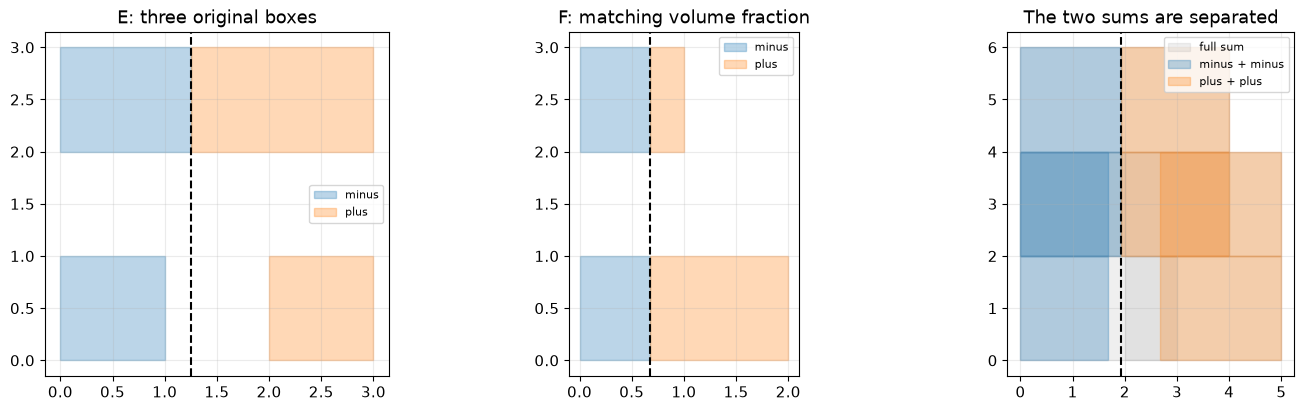

Cut in F: 0.675000; left fraction: 0.450
Full sum area: 28.000000; matching sums: 26.000000; BM lower bound: 15.745967
Original box count: 5; recursive counts: 4 and 4
E alone: 3 boxes before the cut, 4 pieces across both sides afterwards.


In [6]:
E=np.array([[0.,0.,1.,1.],[2.,0.,3.,1.],[0.,2.,3.,3.]])
F=np.array([[0.,0.,2.,1.],[0.,2.,1.,3.]])
c=1.25
result=matching_cut(E,F,c)
if result is None:
    print('Complete the cut functions, then rerun this cell.')
else:
    Em,Ep,Fm,Fp,e,theta=result
    a,b=union_area(E),union_area(F)
    np.testing.assert_allclose([a,b,theta,e],[5.,3.,.45,.675],atol=1e-12)
    np.testing.assert_allclose([union_area(Em)/a,union_area(Fm)/b],theta,atol=1e-12)
    np.testing.assert_allclose([union_area(Ep)/a,union_area(Fp)/b],1-theta,atol=1e-12)
    assert len(Em)<len(E) and len(Ep)<len(E)
    assert len(Fm)<=len(F) and len(Fp)<=len(F)
    minus=rectangle_sums(Em,Fm); plus=rectangle_sums(Ep,Fp)
    full=rectangle_sums(E,F)
    assert minus[:,2].max() <= c+e+1e-12
    assert plus[:,0].min() >= c+e-1e-12
    matching_area=union_area(minus)+union_area(plus)
    lower=(np.sqrt(a)+np.sqrt(b))**2
    assert union_area(full)>=matching_area-1e-11
    assert matching_area>=lower-1e-11
    # Independent tests of the area helper: overlapping rectangles and the lab's simple sum.
    np.testing.assert_allclose(union_area(np.array([[0.,0.,2.,1.],[1.,0.,3.,1.]])),3.)
    simple_E=np.array([[0.,0.,1.,1.],[2.,0.,3.,1.]])
    simple_F=np.array([[0.,0.,2.,1.]])
    np.testing.assert_allclose(union_area(rectangle_sums(simple_E,simple_F)),10.)
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for ax,left,right,cut,title in [(axes[0],Em,Ep,c,'E: three original boxes'),
                                    (axes[1],Fm,Fp,e,'F: matching volume fraction')]:
        draw_boxes(ax,left,'tab:blue','minus')
        draw_boxes(ax,right,'tab:orange','plus')
        ax.axvline(cut,color='black',ls='--'); ax.set_title(title); ax.legend(fontsize=8)
    draw_boxes(axes[2],full,'gray','full sum',alpha=.12)
    draw_boxes(axes[2],minus,'tab:blue','minus + minus')
    draw_boxes(axes[2],plus,'tab:orange','plus + plus')
    axes[2].axvline(c+e,color='black',ls='--'); axes[2].set_title('The two sums are separated')
    axes[2].legend(fontsize=8); plt.show()
    print(f'Cut in F: {e:.6f}; left fraction: {theta:.3f}')
    print(f'Full sum area: {union_area(full):.6f}; matching sums: {matching_area:.6f}; BM lower bound: {lower:.6f}')
    print(f'Original box count: {len(E)+len(F)}; recursive counts: {len(Em)+len(Fm)} and {len(Ep)+len(Fp)}')
    print(f'E alone: {len(E)} boxes before the cut, {len(Em)+len(Ep)} pieces across both sides afterwards.')


**Explain your observations.** Why can the global piece count increase although induction remains valid? Why may the matching sums fail to exhaust the full sum, and why is this harmless?

**Solution guidance:** Each side of E loses at least one of the separated boxes, so each recursive pair has fewer boxes than the original pair. Other boxes can be cut in two, increasing the combined piece count across both sides. The matching sums lie on opposite sides of x=c+e and are contained in the full sum; omitted cross sums can only add points. Area equality is not required for this lower-bound argument. Bisection matches the volume fraction, not the cutting coordinate or the physical width of each set.

**Before submitting:** restart the kernel, run all cells, label your figures, and explain which conclusions require the course theorem rather than these computations.